In [29]:
import os
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    import xgboost as xgb
except:
    xgb = None

import joblib
print('Setup complete')

Setup complete


In [30]:
#  Loading data
DATA_PATH = 'data.csv'
assert os.path.exists(DATA_PATH), 'Dataset not found'
df = pd.read_csv(DATA_PATH)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,7,PAYMENT,30480.84,C1000000,344056.94,313576.10,M2000000,718360.22,748841.06,0,0
1,20,CASH_OUT,26150.57,C1000001,10581.91,10581.91,C3000001,348546.65,374697.22,0,0
2,29,PAYMENT,69190.84,C1000002,168352.83,99161.99,M2000002,587383.60,656574.44,0,0
3,15,DEBIT,161559.70,C1000003,72237.85,72237.85,C3000003,310761.70,472321.40,0,0
4,11,CASH_IN,49345.01,C1000004,116486.11,67141.10,C3000004,999149.57,1048494.58,0,0


In [31]:
# Quick EDA
print('Shape:', df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['isFraud'].value_counts())
print('Fraud Ratio:', df['isFraud'].mean())

Shape: (5000, 11)
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
isFraud
0    4673
1     327
Name: count, dtype: int64
Fraud Ratio: 0.0654


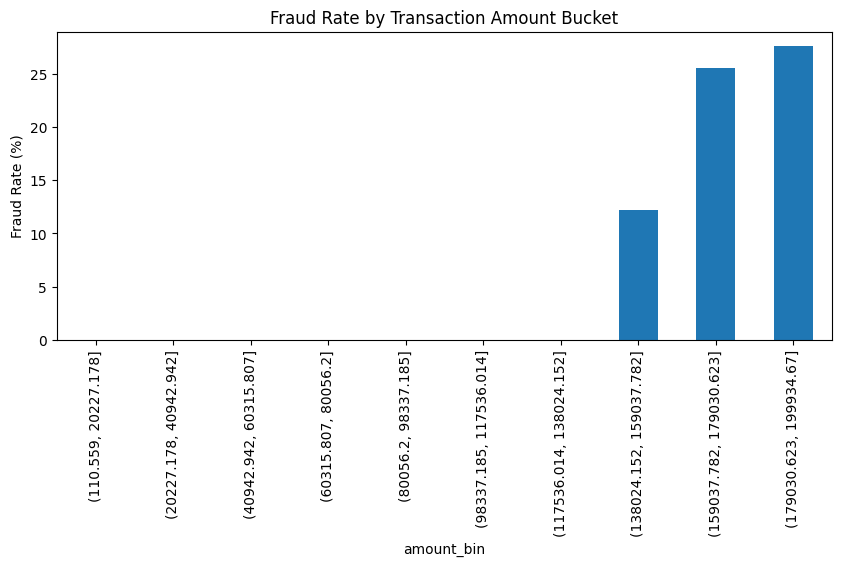

In [32]:
# Fraud Rate by Amount Bucket
df['amount_bin'] = pd.qcut(df['amount'], q=10, duplicates='drop')

fraud_rate = df.groupby('amount_bin')['isFraud'].mean()
fraud_rate = fraud_rate * 100

plt.figure(figsize=(10,4))
fraud_rate.plot(kind='bar')
plt.ylabel("Fraud Rate (%)")
plt.title('Fraud Rate by Transaction Amount Bucket')

plt.show()


In [33]:
# Checking missing values
df.isnull().sum()

# Checking merchant transactions (destination starting with 'M')
merchant_txns = df[df['nameDest'].str.startswith('M')]

merchant_txns[['oldbalanceDest', 'newbalanceDest']].describe()

,oldbalanceDest,newbalanceDest
count,980.000000,9.800000e+02
mean,525282.347020,6.233725e+05
std,285273.995683,2.889889e+05
min,2521.760000,2.385020e+04
25%,276904.710000,3.767355e+05
50%,551761.640000,6.474403e+05
75%,754783.405000,8.587153e+05
max,999299.480000,1.189640e+06


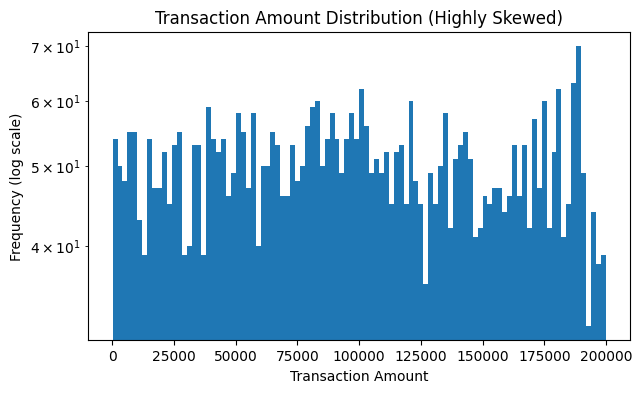

In [34]:
# Outlier Handling
df['amount'].describe()

#Visualize Skewness

plt.figure(figsize=(7,4))
plt.hist(df['amount'], bins=100)
plt.yscale('log')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency (log scale)')
plt.title('Transaction Amount Distribution (Highly Skewed)')
plt.show()

In [35]:
# Log transform to reduce skewness
df['log_amount'] = np.log1p(df['amount'])

# Flag transactions above 99th percentile
p99 = df['amount'].quantile(0.99)
df['is_high_amount'] = (df['amount'] > p99).astype(int)

df['is_high_amount'].value_counts()

is_high_amount
0    4950
1      50
Name: count, dtype: int64

In [36]:
# Overview
total_txns = len(df)
fraud_txns = df['isFraud'].sum()
fraud_rate = fraud_txns / total_txns
fraud_pct = (df['isFraud'].sum() / total_txns) * 100
flagged_pct = (df['isFlaggedFraud'].sum() / total_txns) * 100

print(f"Total transactions: {total_txns:,}")
print(f"Fraud transactions: {fraud_txns:,}")
print(f"Overall fraud rate: {fraud_rate:.4%}")
print(f"Fraudulent transactions (isFraud=1): {fraud_pct:.4f}%")
print(f"Flagged transactions (isFlaggedFraud=1): {flagged_pct:.4f}%")

Total transactions: 5,000
Fraud transactions: 327
Overall fraud rate: 6.5400%
Fraudulent transactions (isFraud=1): 6.5400%
Flagged transactions (isFlaggedFraud=1): 4.0200%


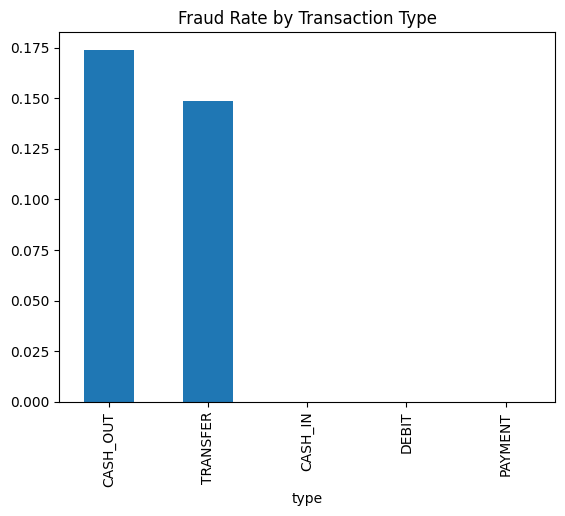

In [37]:
# Fraud Rate by Transaction Type
df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Fraud Rate by Transaction Type')
plt.show()

,hour,total_transactions,fraud_transactions,fraud_rate
0,0,163,8,0.049080
1,1,337,19,0.056380
2,2,356,24,0.067416
3,3,328,22,0.067073
4,4,365,26,0.071233


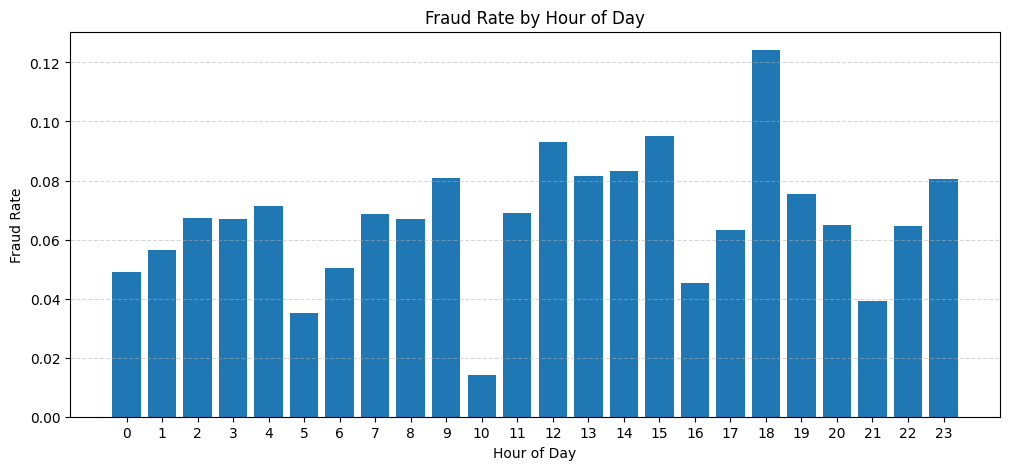

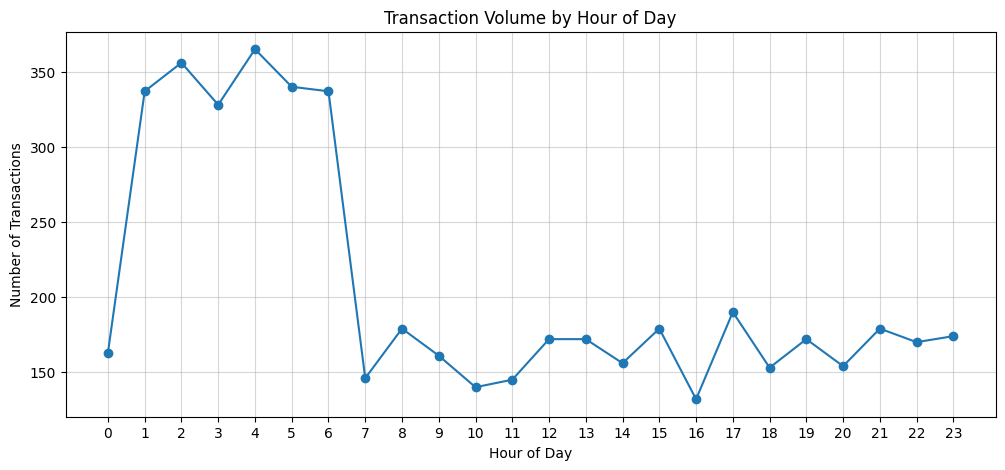

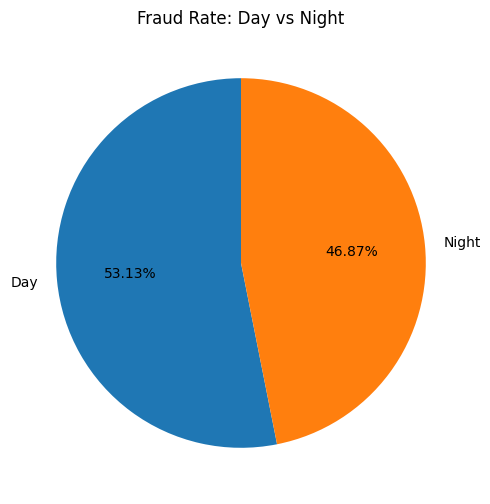

In [38]:
# Time-based overview

df['hour'] = df['step'] % 24

# Aggregate hourly statistics

hourly_stats = (
    df.groupby('hour')
      .agg(
          total_transactions=('isFraud', 'count'),
          fraud_transactions=('isFraud', 'sum'),
          fraud_rate=('isFraud', 'mean')
      )
      .reset_index()
)

display(hourly_stats.head())

# fraud rate by hour

plt.figure(figsize=(12,5))
plt.bar(hourly_stats['hour'], hourly_stats['fraud_rate'])
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of Day')
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# transaction volume by hour 

plt.figure(figsize=(12,5))
plt.plot(hourly_stats['hour'], hourly_stats['total_transactions'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Transaction Volume by Hour of Day')
plt.xticks(range(0,24))
plt.grid(alpha=0.5)
plt.show()

# Day vs Night fraud comparison
plt.figure(figsize=(6,6))

df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

day_night_fraud = (
    df.groupby('is_night')['isFraud']
      .mean()  # average fraud rate
      .rename({0: 'Day', 1: 'Night'})
)

day_night_fraud.plot(
    kind='pie',
    autopct='%1.2f%%',      
    startangle=90,
    legend=False
)

plt.ylabel('') 
plt.title('Fraud Rate: Day vs Night')
plt.show()

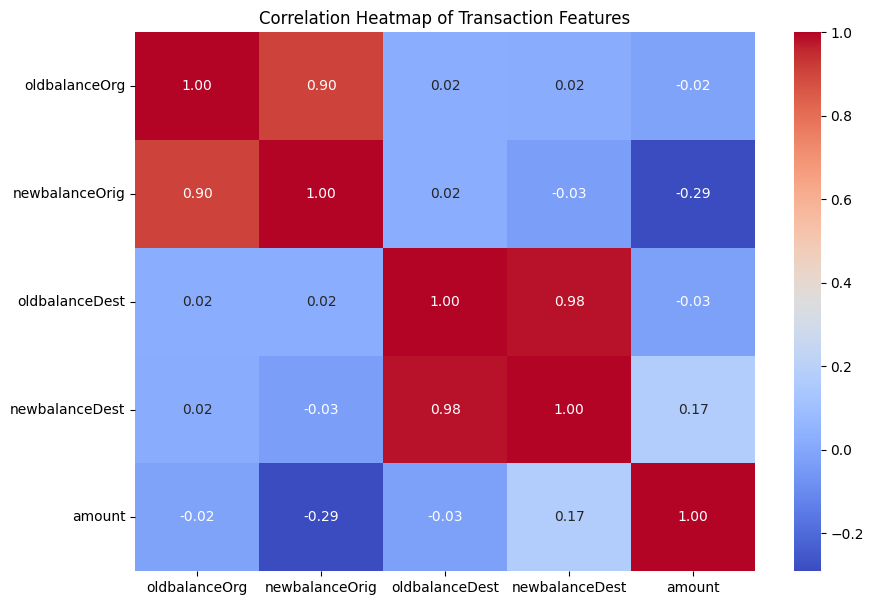

In [39]:
# Correlation Check
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
corr = df[['oldbalanceOrg','newbalanceOrig',
           'oldbalanceDest','newbalanceDest',
           'amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Transaction Features')
plt.show()

Feature Engineering & Data Cleaning

In [40]:
# Feature Engineering – Balance Differences
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']


# Feature Reduction (for linear models here for logistic regression)
df = df.drop(columns=[
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
])

In [41]:
df.drop(columns=['amount_bin'], inplace=True)
df.fillna(0, inplace=True)

le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

df.drop(['nameOrig', 'nameDest', 'type'], axis=1, inplace=True)

Train Test Split

In [42]:
X = df.drop(columns=['isFraud','isFlaggedFraud'])
y = df['isFraud'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = RobustScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Model Training & Evaluation

In [43]:
models = {}

# Logistic Regression 

print("Training Logistic Regression (fast mode)...")
lr = LogisticRegression(
    max_iter=300,                  # reduced iterations
    solver='lbfgs',                
    class_weight='balanced',
    n_jobs=-1
)
lr.fit(X_train, y_train)
models['LogisticRegression'] = lr
print("Logistic Regression trained")

# Random Forest 

print("Training Random Forest (optimized)...")
rf = RandomForestClassifier(
    n_estimators=50,               # reduced trees
    max_depth=12,                  # cap tree growth
    min_samples_leaf=100,          # prevent deep splits
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
models['RandomForest'] = rf
print("Random Forest trained")

# XGBoost 

if xgb is not None:
    print("Training XGBoost (fast hist)...")
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=scale_pos,
        tree_method='hist',         
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model
    print("XGBoost trained")
else:
    print("XGBoost not installed")


Training Logistic Regression (fast mode)...
Logistic Regression trained
Training Random Forest (optimized)...
Random Forest trained
Training XGBoost (fast hist)...
XGBoost trained


In [44]:
results = []
for name, model in models.items():
    if hasattr(model,'predict_proba'):
        scores = model.predict_proba(X_test)[:,1]
    else:
        scores = model.decision_function(X_test)
    print('\n',name)
    print(classification_report(y_test, (scores>0.5).astype(int)))
    results.append({'model':name,'roc_auc':roc_auc_score(y_test,scores),'auprc':average_precision_score(y_test,scores)})

pd.DataFrame(results).sort_values('auprc', ascending=False)


 LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.80      0.89       935
           1       0.25      0.97      0.40        65

    accuracy                           0.81      1000
   macro avg       0.62      0.88      0.64      1000
weighted avg       0.95      0.81      0.86      1000


 RandomForest
              precision    recall  f1-score   support

           0       1.00      0.80      0.89       935
           1       0.26      0.98      0.41        65

    accuracy                           0.81      1000
   macro avg       0.63      0.89      0.65      1000
weighted avg       0.95      0.81      0.86      1000


 XGBoost
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       935
           1       0.63      0.95      0.76        65

    accuracy                           0.96      1000
   macro avg       0.81      0.96      0.87      1000
weighted avg       0.97     

,model,roc_auc,auprc
1,RandomForest,0.970366,0.643850
2,XGBoost,0.976438,0.560693
0,LogisticRegression,0.914866,0.347843


In [45]:
from sklearn.metrics import precision_recall_curve

model = models['XGBoost'] 

y_scores = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Find threshold with recall >= 0.90 and best precision
candidates = [
    (t, p, r) for t, p, r in zip(thresholds, precision[:-1], recall[:-1])
    if r >= 0.90
]

best_threshold, best_p, best_r = max(candidates, key=lambda x: x[1])
print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision: {best_p:.3f}, Recall: {best_r:.3f}")

Best threshold: 0.7591
Precision: 0.634, Recall: 0.908


Fine Tuning the model

In [46]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=4,                 # controls overfitting
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,         # critical for imbalance
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [47]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=200,        # huge impact on precision
    min_samples_split=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",200
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [48]:
lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    C=0.3                     # stronger regularization
)

lr_tuned.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.3
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [49]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate(model, X, y):
    scores = model.predict_proba(X)[:,1]
    return {
        "ROC-AUC": roc_auc_score(y, scores),
        "PR-AUC": average_precision_score(y, scores)
    }

print("XGB:", evaluate(xgb_tuned, X_test, y_test))
print("RF :", evaluate(rf_tuned, X_test, y_test))
print("LR :", evaluate(lr_tuned, X_test, y_test))

XGB: {'ROC-AUC': 0.9768408062525711, 'PR-AUC': 0.6088838737307868}
RF : {'ROC-AUC': 0.9383216783216783, 'PR-AUC': 0.495633684083443}
LR : {'ROC-AUC': 0.9146524064171123, 'PR-AUC': 0.35032011641436045}


Saving the fine tuned model

In [50]:
models = {
    "LogisticRegression": lr_tuned,
    "RandomForest": rf_tuned,
    "XGBoost": xgb_tuned
}

best_model_name = max(results, key=lambda x: x['auprc'])['model']
best_model = models[best_model_name]


best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,     
    "features": X_train.columns.tolist()
}

joblib.dump(best_model_artifact, "best_fraud_model_tuned.pkl")

print(f" Saved best model: {best_model_name}")
print(f" Decision threshold: {best_threshold:.4f}")

 Saved best model: RandomForest
 Decision threshold: 0.7591


In [51]:
# Load saved model artifact
artifact = joblib.load("best_fraud_model_tuned.pkl")
model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]

# Predict on test data
y_scores = model.predict_proba(X_test[features])[:, 1]
y_pred = (y_scores >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Summary table
summary = pd.DataFrame({
    "Count": [tp, fn, fp, tn]
}, index=[
    "Correctly detected fraud (TP)",
    "Missed fraud (FN)",
    "False alarms (FP)",
    "Correct non-fraud (TN)"
])

print(summary)

# quick fraud recall check
print(f"\nFraud Recall: {tp / (tp + fn):.3f}")
print(f"Fraud Precision: {tp / (tp + fp):.3f}")

                               Count
Correctly detected fraud (TP)     63
Missed fraud (FN)                  2
False alarms (FP)                185
Correct non-fraud (TN)           750

Fraud Recall: 0.969
Fraud Precision: 0.254


In [52]:
import joblib

# Save your trained model
joblib.dump(model, 'fraud_model.pkl')

# Later, to load:
# model = joblib.load('fraud_model.pkl')

['fraud_model.pkl']